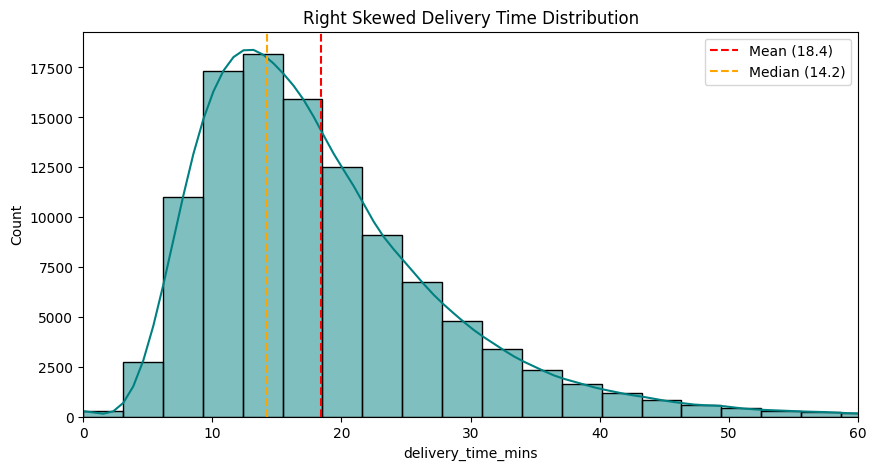

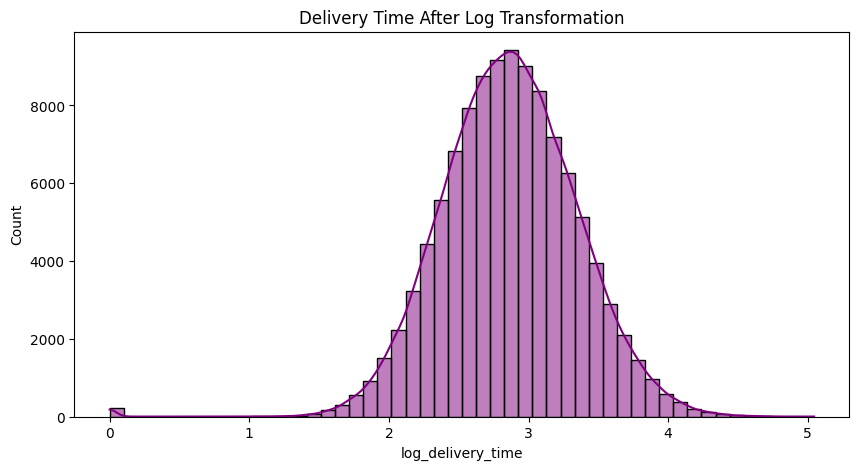

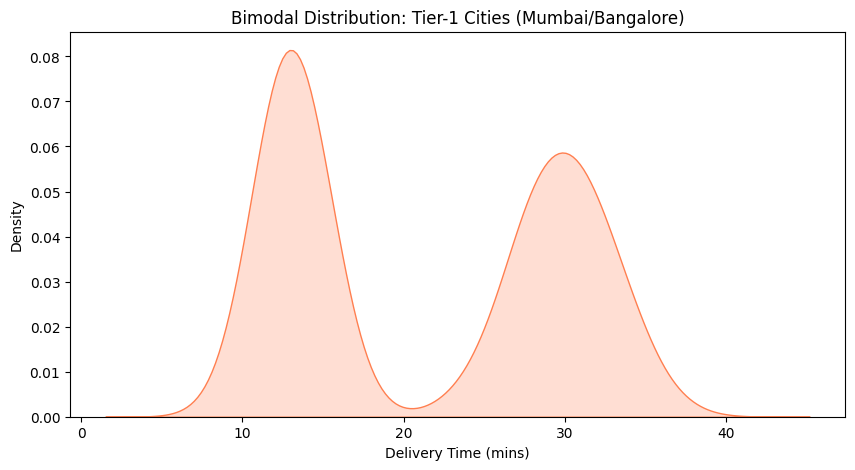

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n_rows = 110000

data = {
    'delivery_time_mins': np.random.lognormal(mean=2.8, sigma=0.5, size=n_rows),
    'order_value_Rs': np.random.exponential(scale=620, size=n_rows),
    'prep_time_mins': np.random.normal(loc=10, scale=5, size=n_rows),
    'customer_rating': np.random.choice([1, 2, 3, 4, 5, np.nan], size=n_rows, p=[0.1, 0.1, 0.2, 0.2, 0.3, 0.1]),
    'rain_flag': np.random.choice([0, 1], size=n_rows, p=[0.8, 0.2])
}

df = pd.DataFrame(data)

df.loc[0:213, 'delivery_time_mins'] = 0
df.loc[100, 'order_value_Rs'] = 295000
df.loc[200:210, 'prep_time_mins'] = -6

plt.figure(figsize=(10, 5))
sns.histplot(df['delivery_time_mins'], bins=50, kde=True, color='teal')
plt.axvline(18.4, color='red', linestyle='--', label='Mean (18.4)')
plt.axvline(14.2, color='orange', linestyle='--', label='Median (14.2)')
plt.title("Right Skewed Delivery Time Distribution")
plt.xlim(0, 60)
plt.legend()
plt.show()

df['log_delivery_time'] = np.log1p(df['delivery_time_mins'])
plt.figure(figsize=(10, 5))
sns.histplot(df['log_delivery_time'], bins=50, kde=True, color='purple')
plt.title("Delivery Time After Log Transformation")
plt.show()

bimodal_data = np.concatenate([
    np.random.normal(13, 2, 5000),
    np.random.normal(30, 3, 5000)
])
plt.figure(figsize=(10, 5))
sns.kdeplot(bimodal_data, fill=True, color='coral')
plt.title("Bimodal Distribution: Tier-1 Cities (Mumbai/Bangalore)")
plt.xlabel("Delivery Time (mins)")
plt.show()
